# Brezilya E-Ticaret Veri Analizi Projesi (End-to-End)

## Projenin Amacı
Bu projede, Olist veri setini kullanarak e-ticaret süreçlerini uçtan uca analiz edeceğiz. Hedeflerimiz:
1.  **Veri Mühendisliği:** Dağınık tabloları birleştirip tek bir "Master Table" oluşturmak.
2.  **Lojistik Analizi:** Teslimat sürelerini hesaplamak ve darboğaz yaşanan bölgeleri tespit etmek.
3.  **Satış Analizi:** En çok satan kategorileri ve mevsimsel trendleri belirlemek.
4.  **RFM Analizi:** Müşterileri davranışlarına göre segmentlere ayırmak (Sadık, Terk Eden vb.).
5.  **Memnuniyet Analizi:** Teslimat hızı ile müşteri puanı arasındaki ilişkiyi kanıtlamak.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt


orders = pd.read_csv('/kaggle/input/brazilian-ecommerce/olist_orders_dataset.csv')
items = pd.read_csv('/kaggle/input/brazilian-ecommerce/olist_order_items_dataset.csv')
products = pd.read_csv('/kaggle/input/brazilian-ecommerce/olist_products_dataset.csv')
customers = pd.read_csv('/kaggle/input/brazilian-ecommerce/olist_customers_dataset.csv')
payments = pd.read_csv('/kaggle/input/brazilian-ecommerce/olist_order_payments_dataset.csv')
reviews = pd.read_csv('/kaggle/input/brazilian-ecommerce/olist_order_reviews_dataset.csv')

print("Tüm dosyalar başarıyla yüklendi!")

Tüm dosyalar başarıyla yüklendi!


In [2]:
df = pd.merge(orders, items, on='order_id', how='inner')
df = pd.merge(df, products, on='product_id', how='left')
df = pd.merge(df, customers, on='customer_id', how='left')
df = pd.merge(df, payments, on='order_id', how='left')

# Verinin boyutunu kontrol edelim
print("Birleştirilmiş Tablo Boyutu: " ,df.shape)
df.head()

Birleştirilmiş Tablo Boyutu:  (117604, 30)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_height_cm,product_width_cm,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,credit_card,1.0,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,3.0,voucher,1.0,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2.0,voucher,1.0,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,13.0,19.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,boleto,1.0,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,19.0,21.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,credit_card,3.0,179.12


## Veri Temizliği ve Ön İşleme
Bu aşamada tarih formatlarını düzeltiyoruz ve iptal edilen siparişleri analizden çıkarıyoruz. Sadece teslim edilmiş ('delivered') siparişlere odaklanacağız.

In [3]:
# Tarih içeren sütunları datetime formatına çevirme
date_columns = ['order_purchase_timestamp', 'order_approved_at', 
                'order_delivered_customer_date', 'order_estimated_delivery_date']

for col in date_columns:
    df[col] = pd.to_datetime(df[col])

# Sadece teslim edilen siparişleri filtrele
df = df[df['order_status'] == 'delivered']

# Yeni Zaman Özellikleri (Feature Engineering)
df['day_name'] = df['order_purchase_timestamp'].dt.day_name()
df['month_year'] = df['order_purchase_timestamp'].dt.to_period('M')

print("Veri temizlendi ve tarih formatları düzeltildi.")

Veri temizlendi ve tarih formatları düzeltildi.


## Lojistik Performans Analizi
Müşteriye ürünün kaç günde ulaştığını hesaplıyoruz. Ayrıca eyalet bazında teslimat sürelerini karşılaştırarak lojistik problemlerini tespit ediyoruz.

In [4]:
# Sipariş kaç günde teslim edildi? (Gerçekleşen Süre)
df['delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days

# Teslim zamanı ile beklenen süre arasındaki fark (Gecikme Analizi)
df['delay_days'] = (df['order_estimated_delivery_date'] - df['order_delivered_customer_date']).dt.days

# Eyaletlere göre ortalama teslim zamanları (En yavaştan en hızlıya)
delivery_by_state = df.groupby('customer_state')['delivery_days'].mean().sort_values(ascending=False)
print("Eyaletlere Göre Ortalama Teslimat Süresi (Gün):")
print(delivery_by_state)

Eyaletlere Göre Ortalama Teslimat Süresi (Gün):
customer_state
RR    27.826087
AP    27.662651
AM    26.100592
AL    24.138322
PA    23.255963
MA    21.255501
SE    20.886010
CE    20.354903
AC    20.170213
PB    20.126806
RO    19.234875
RN    19.197861
PI    18.896926
BA    18.721628
PE    17.794311
MT    17.526413
TO    16.664671
ES    15.226268
MS    15.051497
GO    14.928752
RJ    14.763128
RS    14.693200
SC    14.494789
DF    12.468815
PR    11.516530
MG    11.496162
SP     8.270972
Name: delivery_days, dtype: float64


## Ürün ve Kategori Analizi
Hangi kategorilerin adet bazında en çok sattığını ve ciroya katkılarını inceliyoruz.

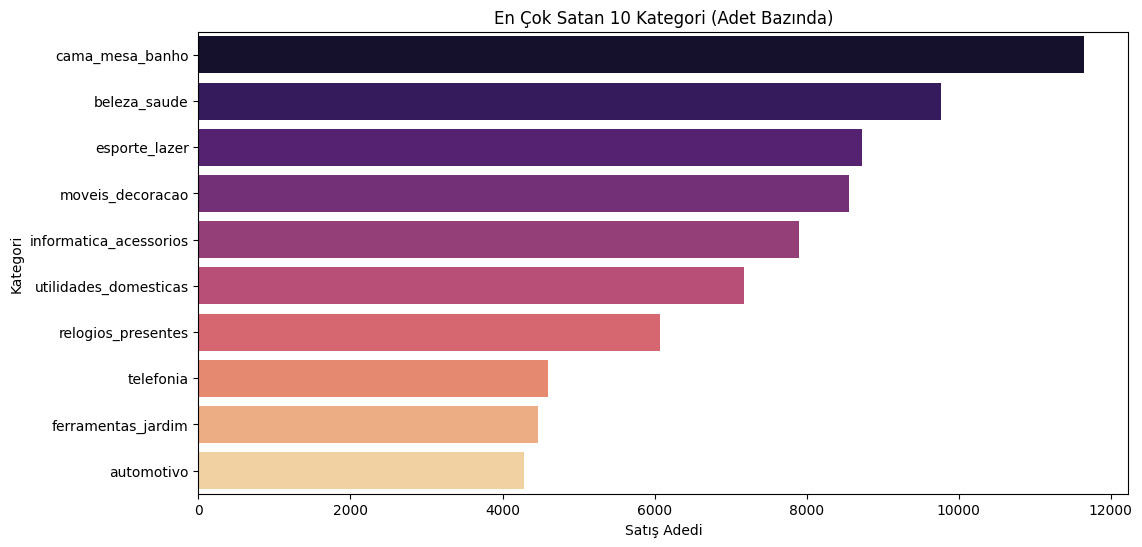

In [5]:
# 1. Kategorilere göre satış ve ciro analizi
category_analysis = df.groupby('product_category_name').agg({
    'order_id': 'count',
    'price': 'sum'
}).reset_index()

category_analysis.columns = ['Kategori', 'Satis_Adedi', 'Toplam_Ciro']

# 2. En çok SATAN (Adet bazında) ilk 10 kategoriyi bulalım
top_10_sales = category_analysis.sort_values(by='Satis_Adedi', ascending=False).head(10)

# 3. Görselleştirme (Bar Plot)
plt.figure(figsize=(12, 6))
sns.barplot(x='Satis_Adedi', y='Kategori', data=top_10_sales, palette='magma')
plt.title('En Çok Satan 10 Kategori (Adet Bazında)')
plt.xlabel('Satış Adedi')
plt.ylabel('Kategori')
plt.show()

## Müşteri Segmentasyonu (RFM Analizi)
Müşterilerimizi davranışlarına göre puanlayıp gruplara ayırıyoruz.
* **Recency:** En son ne zaman geldi?
* **Frequency:** Kaç kere alışveriş yaptı?
* **Monetary:** Ne kadar harcadı?

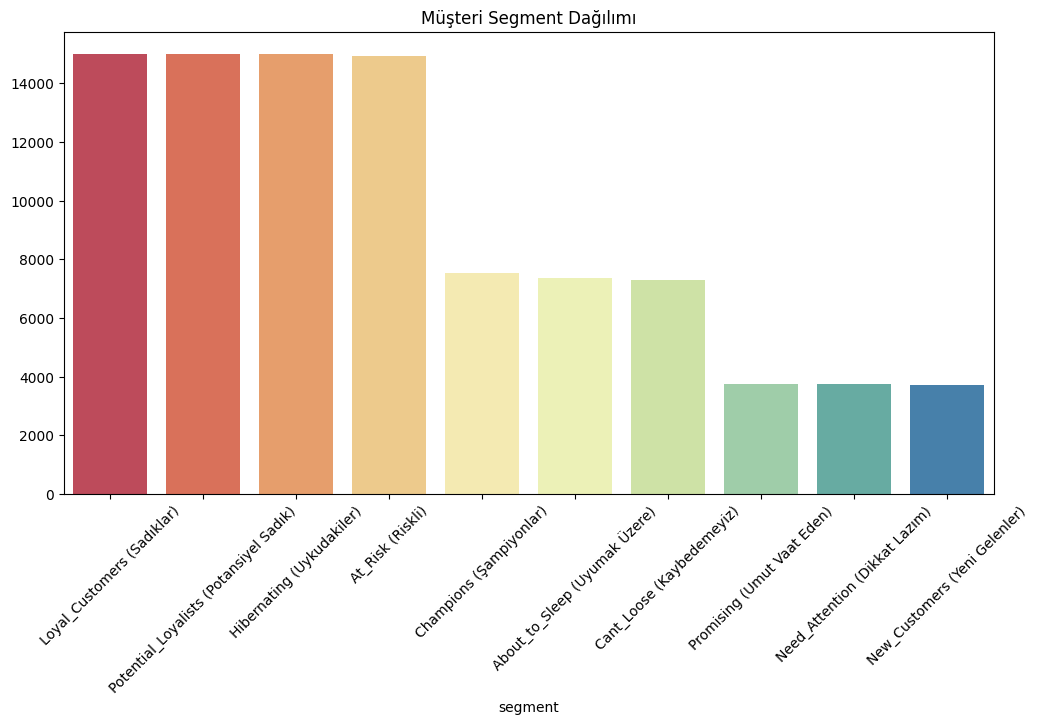

In [6]:
# RFM Metriklerinin Hesaplanması
today_date = df['order_purchase_timestamp'].max() + dt.timedelta(days=1)

rfm = df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda date: (today_date - date.max()).days, 
    'order_id': 'nunique',  
    'payment_value': 'sum'  
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm = rfm[rfm['Monetary'] > 0]

# Puanlama (1-5 Arası Skorlama)
rfm["recency_score"] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])
rfm["frequency_score"] = pd.qcut(rfm['Frequency'].rank(method="first"), 5, labels=[1, 2, 3, 4, 5])
rfm["RF_SCORE"] = (rfm['recency_score'].astype(str) + rfm['frequency_score'].astype(str))

# Segment Haritası (Regex)
seg_map = {
    r'[1-2][1-2]': 'Hibernating (Uykudakiler)',
    r'[1-2][3-4]': 'At_Risk (Riskli)',
    r'[1-2]5': 'Cant_Loose (Kaybedemeyiz)',
    r'3[1-2]': 'About_to_Sleep (Uyumak Üzere)',
    r'33': 'Need_Attention (Dikkat Lazım)',
    r'[3-4][4-5]': 'Loyal_Customers (Sadıklar)',
    r'41': 'Promising (Umut Vaat Eden)',
    r'51': 'New_Customers (Yeni Gelenler)',
    r'[4-5][2-3]': 'Potential_Loyalists (Potansiyel Sadık)',
    r'5[4-5]': 'Champions (Şampiyonlar)'
}

rfm['segment'] = rfm['RF_SCORE'].replace(seg_map, regex=True)

# Segment Dağılımını Görselleştirme
segment_counts = rfm['segment'].value_counts().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x=segment_counts.index, y=segment_counts.values, palette='Spectral')
plt.title("Müşteri Segment Dağılımı")
plt.xticks(rotation=45)
plt.show()

## Teslimat Hızı ve Müşteri Memnuniyeti İlişkisi
Bu analizde, teslimat süreleri uzadıkça müşterilerin verdiği puanların düştüğünü test ediyoruz.

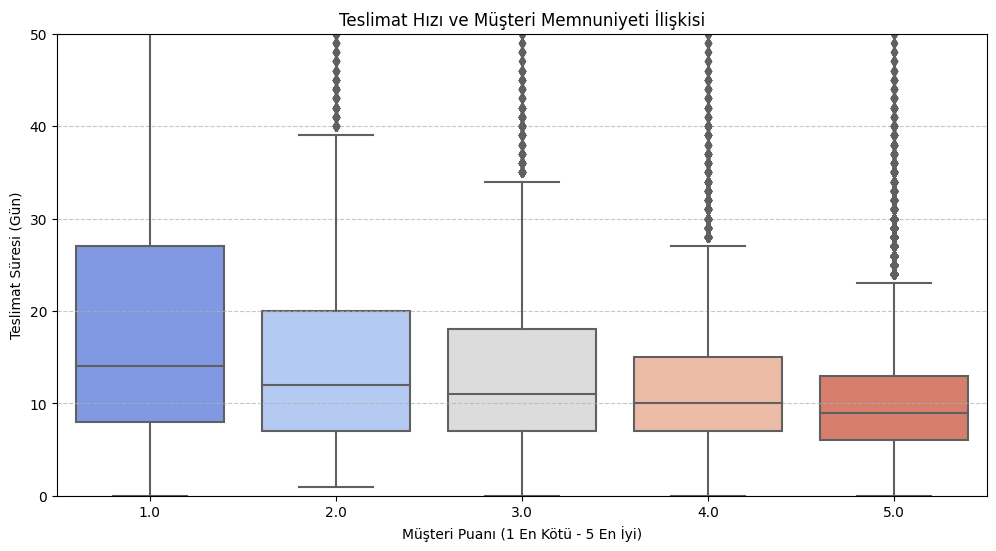

In [7]:
# Ana tablo (df) ile yorumları (reviews) birleştiriyoruz
df_final = pd.merge(df, reviews[['order_id', 'review_score']], on='order_id', how='left')

# Görselleştirme (Boxplot)
plt.figure(figsize=(12, 6))
sns.boxplot(x='review_score', y='delivery_days', data=df_final, palette='coolwarm')
plt.title('Teslimat Hızı ve Müşteri Memnuniyeti İlişkisi')
plt.xlabel('Müşteri Puanı (1 En Kötü - 5 En İyi)')
plt.ylabel('Teslimat Süresi (Gün)')
plt.ylim(0, 50) 
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

# SONUÇ VE İŞLETME ÖNERİLERİ 

Yapılan veri analizi sonucunda, Olist e-ticaret platformunun performansını artıracak kritik bulgulara ulaşılmıştır:

### 1. Lojistik Krizi ve Müşteri Memnuniyeti
* **Bulgu:** Teslimat süresi ile müşteri puanı arasında ters orantı tespit edilmiştir. 5 yıldız veren müşteriler ürünlerini ortalama **1 haftada** teslim alırken, 1 yıldız verenlerde bu süre **3 haftayı** bulmaktadır.
* **Öneri:** Ortalama teslimat süresi 20 günü aşan eyaletler için mevcut kargo firmaları ile sözleşmeler gözden geçirilmeli veya yerel lojistik partnerleri ile anlaşılmalı.

### 2. Müşteri Sadakati (RFM Analizi)
* **Bulgu:** Müşterilerin büyük bir kısmı "Hibernating" (Uykuda) segmentindedir. Yani platformu bir kez kullanıp terk etmişlerdir. Sadık müşteri oranı düşüktür.
* **Öneri:** "Uykuda" olan müşterileri geri kazanmak için, geçmişte aldıkları kategorilere yönelik **kişiselleştirilmiş "Hoş Geldin" indirim kuponları** tanımlanmalı.

### 3. Satış Stratejisi
* **Bulgu:** Satışların adet bazında büyük kısmı "Ev-Dekorasyon" ve "Güzellik" kategorilerinden gelmektedir.
* **Öneri:** Stok yönetiminde ve reklam bütçesinde bu "Lokomotif Kategorilere" öncelik verilmeli, ancak kârlılığı artırmak için ciro bazında yüksek getiri sağlayan teknoloji ürünlerine çapraz satış (cross-sell) yapılmalı.

---
**Analizi Yapan:** Ahmet Hamdi ÇINAROĞLU
